In [1]:
#import the important libraries 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**DATA PREPARATION & ALIGNMENT**

In [2]:
print("--- STARTING DATA PIPELINE ---")

#1. Load Data
HL_PATH = '/kaggle/input/datasets/engineeringmix/stock-market-dataset/historical_data.csv'
FG_PATH = '/kaggle/input/datasets/engineeringmix/stock-market-dataset/fear_greed_index.csv'

df_trades = pd.read_csv(HL_PATH)
df_fg = pd.read_csv(FG_PATH)

df_trades.columns = df_trades.columns.str.strip()
df_fg.columns = df_fg.columns.str.strip()

print(f"Loaded Trades: {df_trades.shape[0]} rows | Loaded F&G: {df_fg.shape[0]} rows")

--- STARTING DATA PIPELINE ---
Loaded Trades: 211224 rows | Loaded F&G: 2644 rows


In [3]:
print(df_trades.head())

                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
2       144.09   1150.63  BUY  02-12-2024 22:50     1002.518996       Buy   
3       142.98   1142.04  BUY  02-12-2024 22:50     1146.558564       Buy   
4         8.73     69.75  BUY  02-12-2024 22:50     1289.488521       Buy   

   Closed PnL                                   Transaction Hash     Order ID  \
0         0.0  0xec0945

In [4]:
print(df_fg.head())

    timestamp  value classification        date
0  1517463000     30           Fear  2018-02-01
1  1517549400     15   Extreme Fear  2018-02-02
2  1517635800     40           Fear  2018-02-03
3  1517722200     24   Extreme Fear  2018-02-04
4  1517808600     11   Extreme Fear  2018-02-05


In [5]:
print(df_trades.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(

In [6]:
print(df_fg.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB
None


In [7]:
print(df_trades.describe())

       Execution Price   Size Tokens      Size USD  Start Position  \
count    211224.000000  2.112240e+05  2.112240e+05    2.112240e+05   
mean      11414.723350  4.623365e+03  5.639451e+03   -2.994625e+04   
std       29447.654868  1.042729e+05  3.657514e+04    6.738074e+05   
min           0.000005  8.740000e-07  0.000000e+00   -1.433463e+07   
25%           4.854700  2.940000e+00  1.937900e+02   -3.762311e+02   
50%          18.280000  3.200000e+01  5.970450e+02    8.472793e+01   
75%         101.580000  1.879025e+02  2.058960e+03    9.337278e+03   
max      109004.000000  1.582244e+07  3.921431e+06    3.050948e+07   

          Closed PnL      Order ID            Fee      Trade ID     Timestamp  
count  211224.000000  2.112240e+05  211224.000000  2.112240e+05  2.112240e+05  
mean       48.749001  6.965388e+10       1.163967  5.628549e+14  1.737744e+12  
std       919.164828  1.835753e+10       6.758854  3.257565e+14  8.689920e+09  
min   -117990.104100  1.732711e+08      -1.175712

In [8]:
print(df_fg.describe())

          timestamp        value
count  2.644000e+03  2644.000000
mean   1.631899e+09    46.981089
std    6.597967e+07    21.827680
min    1.517463e+09     5.000000
25%    1.574811e+09    28.000000
50%    1.631900e+09    46.000000
75%    1.688989e+09    66.000000
max    1.746164e+09    95.000000


In [9]:
#2 Missing Values
print("\nTrade Missing Values:\n", df_trades.duplicated().isnull().sum().max())
print("\nFear/Greed Missing Values:\n", df_fg.duplicated().isnull().sum().max())


Trade Missing Values:
 0

Fear/Greed Missing Values:
 0


In [10]:
# 3. Time Series Alignment (The Critical Step)
# Fear/Greed: 10-digit timestamp (seconds)
# Reload df_fg to ensure 'timestamp' column is present for processing
df_fg = pd.read_csv(FG_PATH)
df_fg['date'] = pd.to_datetime(df_fg['timestamp'], unit='s', utc=True).dt.floor('D')
df_fg = df_fg[['date', 'classification', 'value']]

# Trades: 13-digit timestamp (milliseconds)
df_trades['date'] = pd.to_datetime(df_trades['Timestamp'], unit='ms', utc=True).dt.floor('D')
df_trades['Side'] = df_trades['Side'].astype(str).str.upper()
df_trades['is_win'] = (df_trades['Closed PnL'] > 0).astype(int)

# Merge
df_merged = pd.merge(df_trades, df_fg, on='date', how='left')
df_merged = df_merged.dropna(subset=['classification'])

**METRIC CREATION & SEGMENTATION**

In [11]:
# 1. Calculate Daily Metrics per Trader
daily_stats = df_merged.groupby(['Account', 'date', 'classification']).agg(
    daily_pnl=('Closed PnL', 'sum'),
    total_trades=('Trade ID', 'count'),
    win_rate=('is_win', 'mean'),
    avg_trade_size=('Size USD', 'mean'),
    buy_vol=('Size USD', lambda x: df_merged.loc[x.index, 'Size USD'][df_merged.loc[x.index, 'Side'] == 'BUY'].sum()),
    sell_vol=('Size USD', lambda x: df_merged.loc[x.index, 'Size USD'][df_merged.loc[x.index, 'Side'] == 'SELL'].sum())
).reset_index()

# Long/Short Ratio
daily_stats['total_vol'] = daily_stats['buy_vol'] + daily_stats['sell_vol']
daily_stats['long_ratio'] = np.where(daily_stats['total_vol'] > 0, daily_stats['buy_vol'] / daily_stats['total_vol'], 0.5)

In [12]:
# 2. Segment Traders
size_75th = daily_stats['avg_trade_size'].quantile(0.75)
daily_stats['trader_type'] = np.where(daily_stats['avg_trade_size'] >= size_75th, 'Whale', 'Plankton')

freq_75th = daily_stats['total_trades'].quantile(0.75)
daily_stats['trade_freq'] = np.where(daily_stats['total_trades'] >= freq_75th, 'High-Freq', 'Low-Freq')

**ANALYSIS & VISUALIZATION**


--- GENERATING CHARTS ---


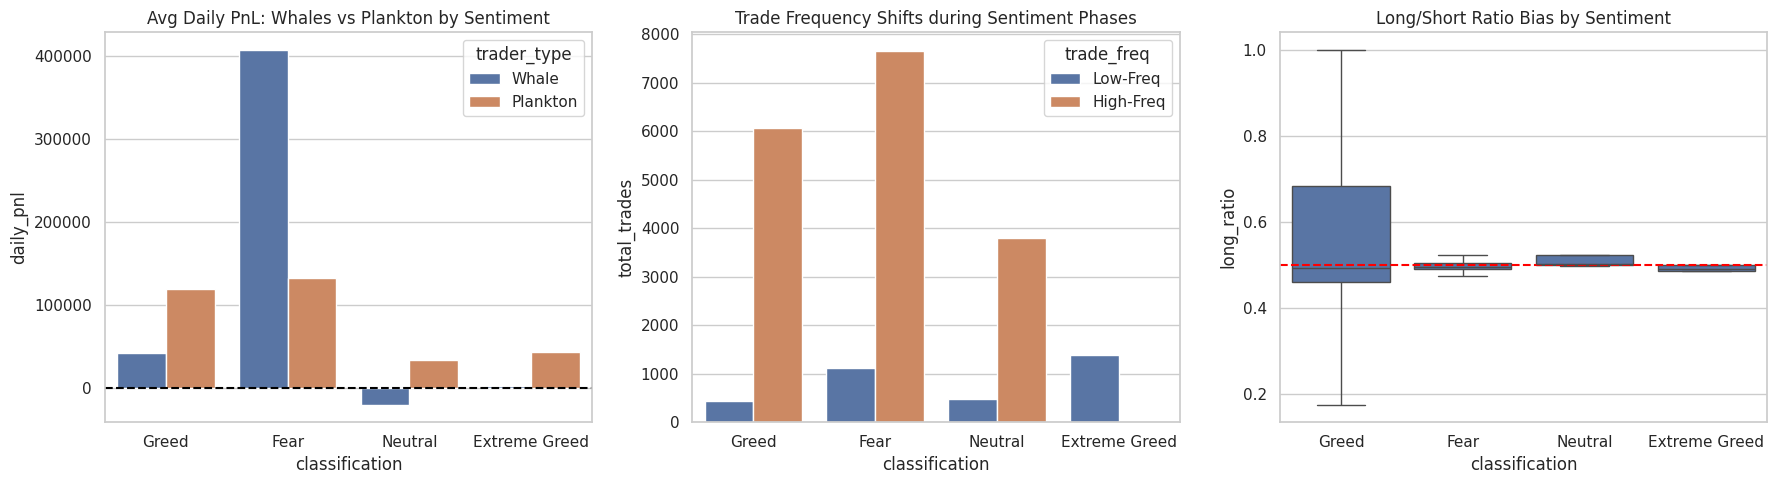

--- PIPELINE COMPLETE ---


In [13]:
print("\n--- GENERATING CHARTS ---")
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Chart 1: PnL vs Sentiment
sns.barplot(data=daily_stats, x='classification', y='daily_pnl', hue='trader_type', ax=axes[0], errorbar=None)
axes[0].set_title('Avg Daily PnL: Whales vs Plankton by Sentiment')
axes[0].axhline(0, color='black', linestyle='--')

# Chart 2: Behavior Shift (Trade Frequency)
sns.barplot(data=daily_stats, x='classification', y='total_trades', hue='trade_freq', ax=axes[1], errorbar=None)
axes[1].set_title('Trade Frequency Shifts during Sentiment Phases')

# Chart 3: Long/Short Bias
sns.boxplot(data=daily_stats, x='classification', y='long_ratio', ax=axes[2], showfliers=False)
axes[2].set_title('Long/Short Ratio Bias by Sentiment')
axes[2].axhline(0.5, color='red', linestyle='--') # 0.5 is neutral

plt.tight_layout()
plt.show()

print("--- PIPELINE COMPLETE ---")